# Bank Bankruptcy Dataset - Exploratory Data Analysis

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load dataset
df = pd.read_csv('data-bank.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (6819, 96)


## 1. Dataset Overview

In [42]:
# Display basic information
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
print(f"\nDataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print("\nFirst few rows:")
print(df.head())
print("\nColumn Names and Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum().sum(), "missing values in total")
if df.isnull().sum().sum() == 0:
    print("✓ No missing values detected!")

DATASET INFORMATION

Dataset Shape: (6819, 96)
Total Records: 6819
Total Features: 96

First few rows:
   Bankrupt?   ROA(C) before interest and depreciation before interest  \
0          1                                           0.370594          
1          1                                           0.464291          
2          1                                           0.426071          
3          1                                           0.399844          
4          1                                           0.465022          

    ROA(A) before interest and % after tax  \
0                                 0.424389   
1                                 0.538214   
2                                 0.499019   
3                                 0.451265   
4                                 0.538432   

    ROA(B) before interest and depreciation after tax  \
0                                           0.405750    
1                                           0.516730    
2   

## 2. Target Variable Analysis


TARGET VARIABLE DISTRIBUTION

Bankruptcy Status:
  Non-Bankrupt (0): 6599 samples (96.77%)
  Bankrupt (1): 220 samples (3.23%)


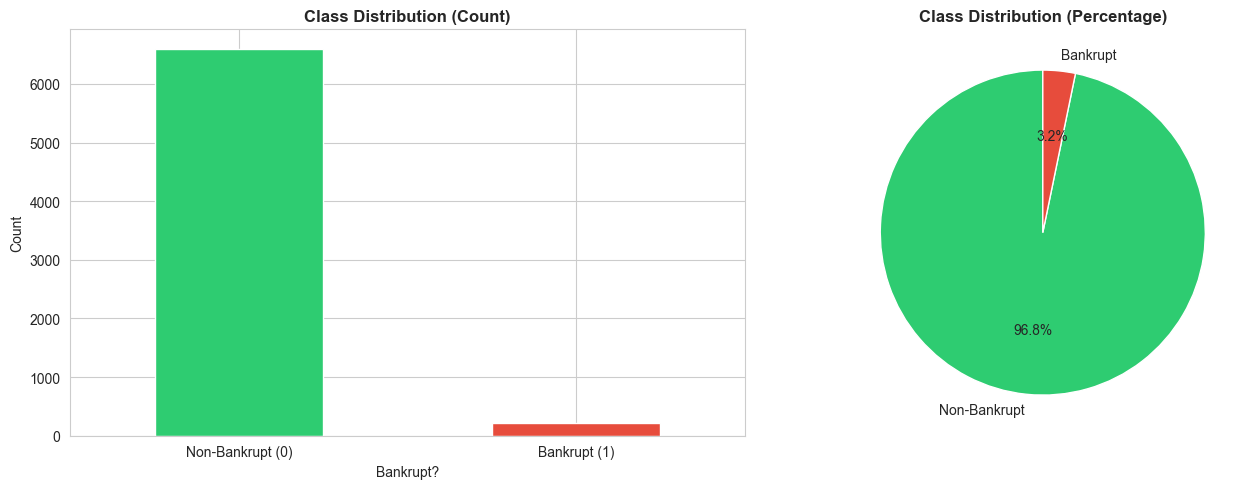


⚠ Class Imbalance Ratio: 6599/220 = 30.00:1


In [43]:
# Analyze target variable (Bankrupt?)
print("\n" + "=" * 80)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 80)

target_counts = df['Bankrupt?'].value_counts().sort_index()
target_pct = df['Bankrupt?'].value_counts(normalize=True).sort_index() * 100

print("\nBankruptcy Status:")
for idx in target_counts.index:
    status = "Bankrupt" if idx == 1 else "Non-Bankrupt"
    print(f"  {status} ({idx}): {target_counts[idx]} samples ({target_pct[idx]:.2f}%)")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
df['Bankrupt?'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Bankrupt?')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Non-Bankrupt (0)', 'Bankrupt (1)'], rotation=0)

# Pie chart
labels = ['Non-Bankrupt', 'Bankrupt']
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(target_counts.values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Class Distribution (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n⚠ Class Imbalance Ratio: {target_counts[0]}/{target_counts[1]} = {target_counts[0]/target_counts[1]:.2f}:1")

## 3. Statistical Summary

In [44]:
print("\n" + "=" * 80)
print("STATISTICAL SUMMARY (excluding target variable)")
print("=" * 80)
print("\nDescriptive Statistics:")
print(df.describe().T)


STATISTICAL SUMMARY (excluding target variable)

Descriptive Statistics:
                                                     count      mean  \
Bankrupt?                                           6819.0  0.032263   
 ROA(C) before interest and depreciation before...  6819.0  0.505180   
 ROA(A) before interest and % after tax             6819.0  0.558625   
 ROA(B) before interest and depreciation after tax  6819.0  0.553589   
 Operating Gross Margin                             6819.0  0.607948   
...                                                    ...       ...   
 Liability to Equity                                6819.0  0.280365   
 Degree of Financial Leverage (DFL)                 6819.0  0.027541   
 Interest Coverage Ratio (Interest expense to E...  6819.0  0.565358   
 Net Income Flag                                    6819.0  1.000000   
 Equity to Liability                                6819.0  0.047578   

                                                         std 

## 4. Feature Correlation Analysis


FEATURE CORRELATION WITH TARGET VARIABLE

Top 15 Positively Correlated Features:
Debt ratio %                                   0.250161
Current Liability to Assets                    0.194494
Borrowing dependency                           0.176543
Current Liability to Current Assets            0.171306
Liability to Equity                            0.166812
Current Liabilities/Equity                     0.153828
Current Liability to Equity                    0.153828
Liability-Assets Flag                          0.139212
Total expense/Assets                           0.139049
Equity to Long-term Liability                  0.139014
Cash/Current Liability                         0.077921
Inventory and accounts receivable/Net value    0.075278
Fixed Assets Turnover Frequency                0.072818
Contingent liabilities/Net worth               0.070455
Fixed Assets to Assets                         0.066328
Name: Bankrupt?, dtype: float64

Top 15 Negatively Correlated Features:
Net Va

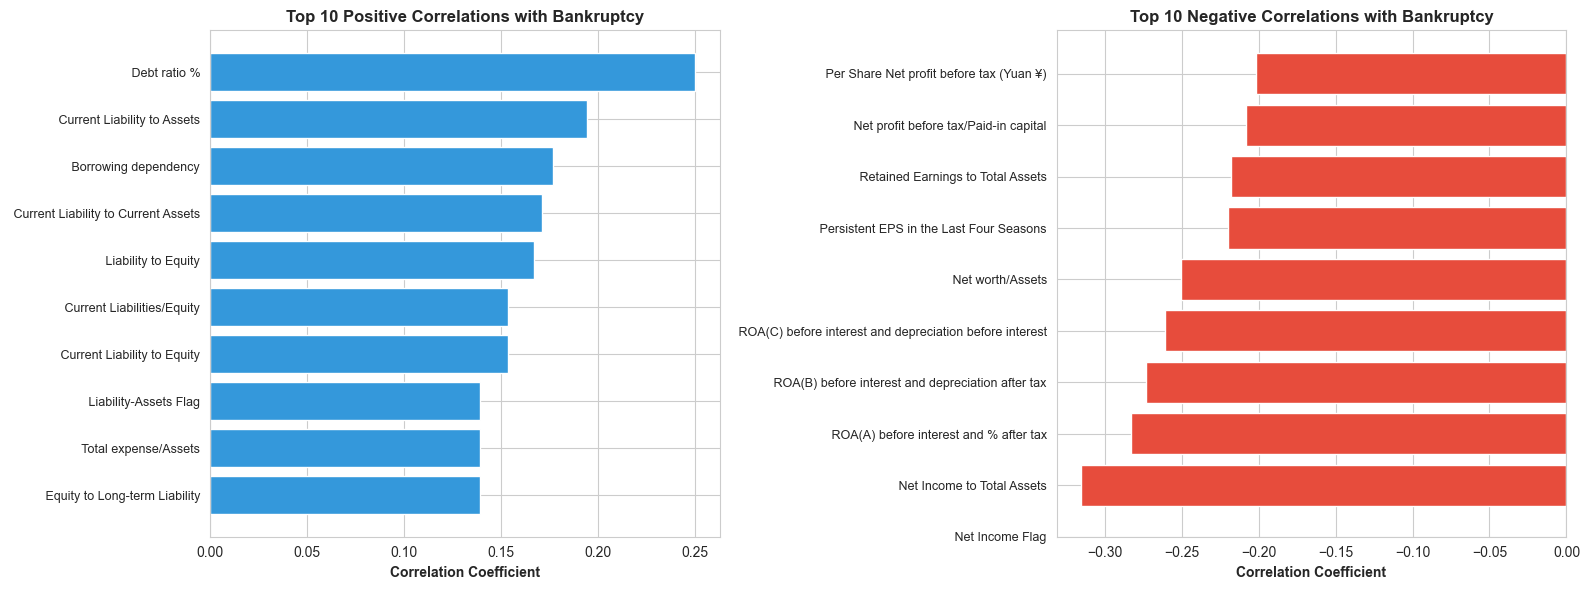

In [45]:
# Correlation with target variable
print("\n" + "=" * 80)
print("FEATURE CORRELATION WITH TARGET VARIABLE")
print("=" * 80)

correlation_with_target = df.corr()['Bankrupt?'].drop('Bankrupt?').sort_values(ascending=False)
print("\nTop 15 Positively Correlated Features:")
print(correlation_with_target.head(15))
print("\nTop 15 Negatively Correlated Features:")
print(correlation_with_target.tail(15))

# Visualize top correlations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top positive correlations
top_positive = correlation_with_target.head(10)
axes[0].barh(range(len(top_positive)), top_positive.values, color='#3498db')
axes[0].set_yticks(range(len(top_positive)))
axes[0].set_yticklabels(top_positive.index, fontsize=9)
axes[0].set_xlabel('Correlation Coefficient', fontweight='bold')
axes[0].set_title('Top 10 Positive Correlations with Bankruptcy', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# Top negative correlations
top_negative = correlation_with_target.tail(10)
axes[1].barh(range(len(top_negative)), top_negative.values, color='#e74c3c')
axes[1].set_yticks(range(len(top_negative)))
axes[1].set_yticklabels(top_negative.index, fontsize=9)
axes[1].set_xlabel('Correlation Coefficient', fontweight='bold')
axes[1].set_title('Top 10 Negative Correlations with Bankruptcy', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

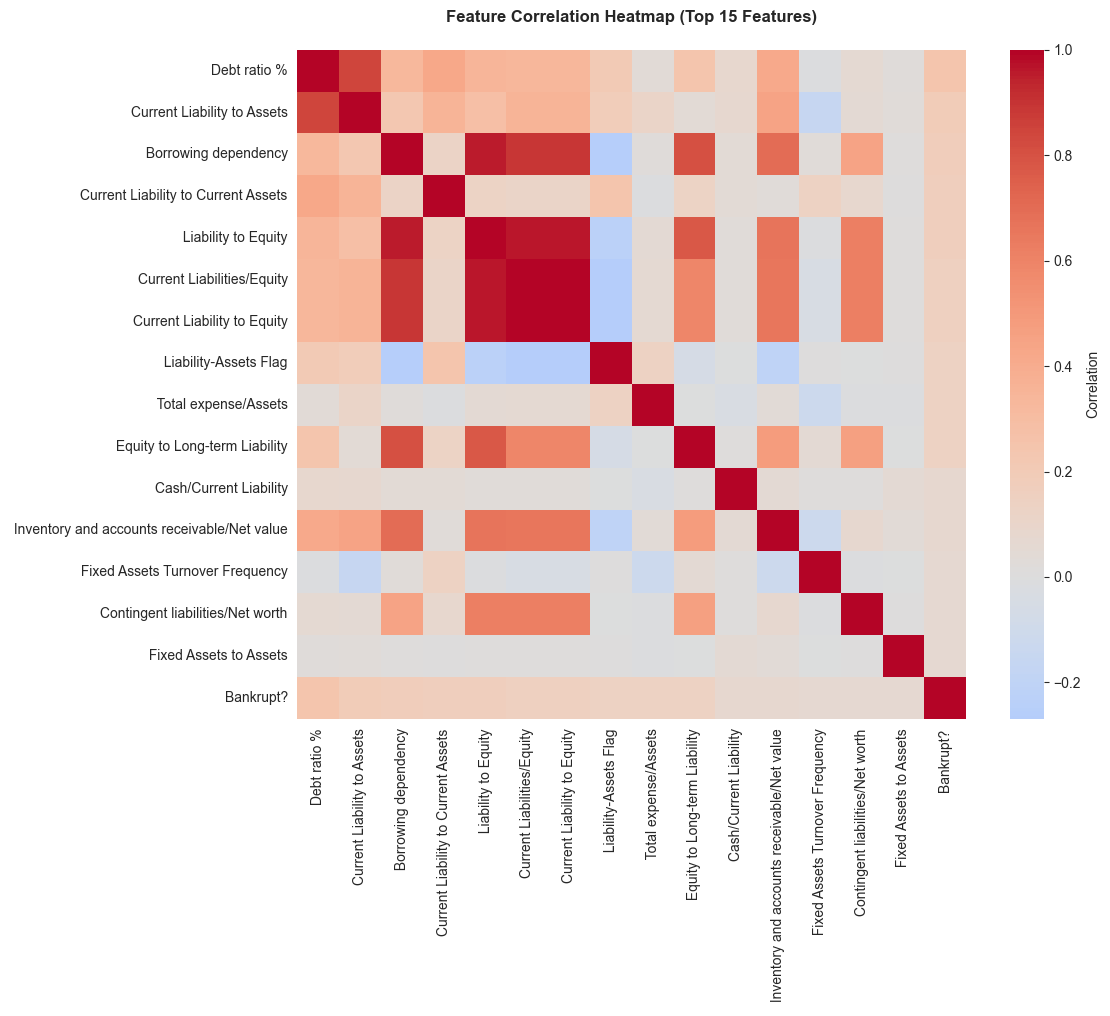

In [46]:
# Feature-to-feature correlation heatmap (sample of top features)
fig, ax = plt.subplots(figsize=(12, 10))

# Select top correlated features
top_features = list(correlation_with_target.head(15).index) + ['Bankrupt?']
correlation_matrix = df[top_features].corr()

# Create heatmap
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Feature Correlation Heatmap (Top 15 Features)', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 5. Distribution Analysis by Bankruptcy Status


FEATURE COMPARISON: BANKRUPT vs NON-BANKRUPT

Analyzing top 5 most correlated features:
[' Net Income to Total Assets', ' ROA(A) before interest and % after tax', ' ROA(B) before interest and depreciation after tax', ' ROA(C) before interest and depreciation before interest', ' Net worth/Assets']

 Net Income to Total Assets:
  Non-Bankrupt - Mean: 0.810083, Std: 0.035991
  Bankrupt - Mean: 0.738083, Std: 0.081092

 ROA(A) before interest and % after tax:
  Non-Bankrupt - Mean: 0.562015, Std: 0.060898
  Bankrupt - Mean: 0.456947, Std: 0.107674

 ROA(B) before interest and depreciation after tax:
  Non-Bankrupt - Mean: 0.556659, Std: 0.057864
  Bankrupt - Mean: 0.461483, Std: 0.091825

 ROA(C) before interest and depreciation before interest:
  Non-Bankrupt - Mean: 0.508069, Std: 0.057694
  Bankrupt - Mean: 0.418503, Std: 0.081068

 Net worth/Assets:
  Non-Bankrupt - Mean: 0.889286, Std: 0.052071
  Bankrupt - Mean: 0.812953, Std: 0.056234


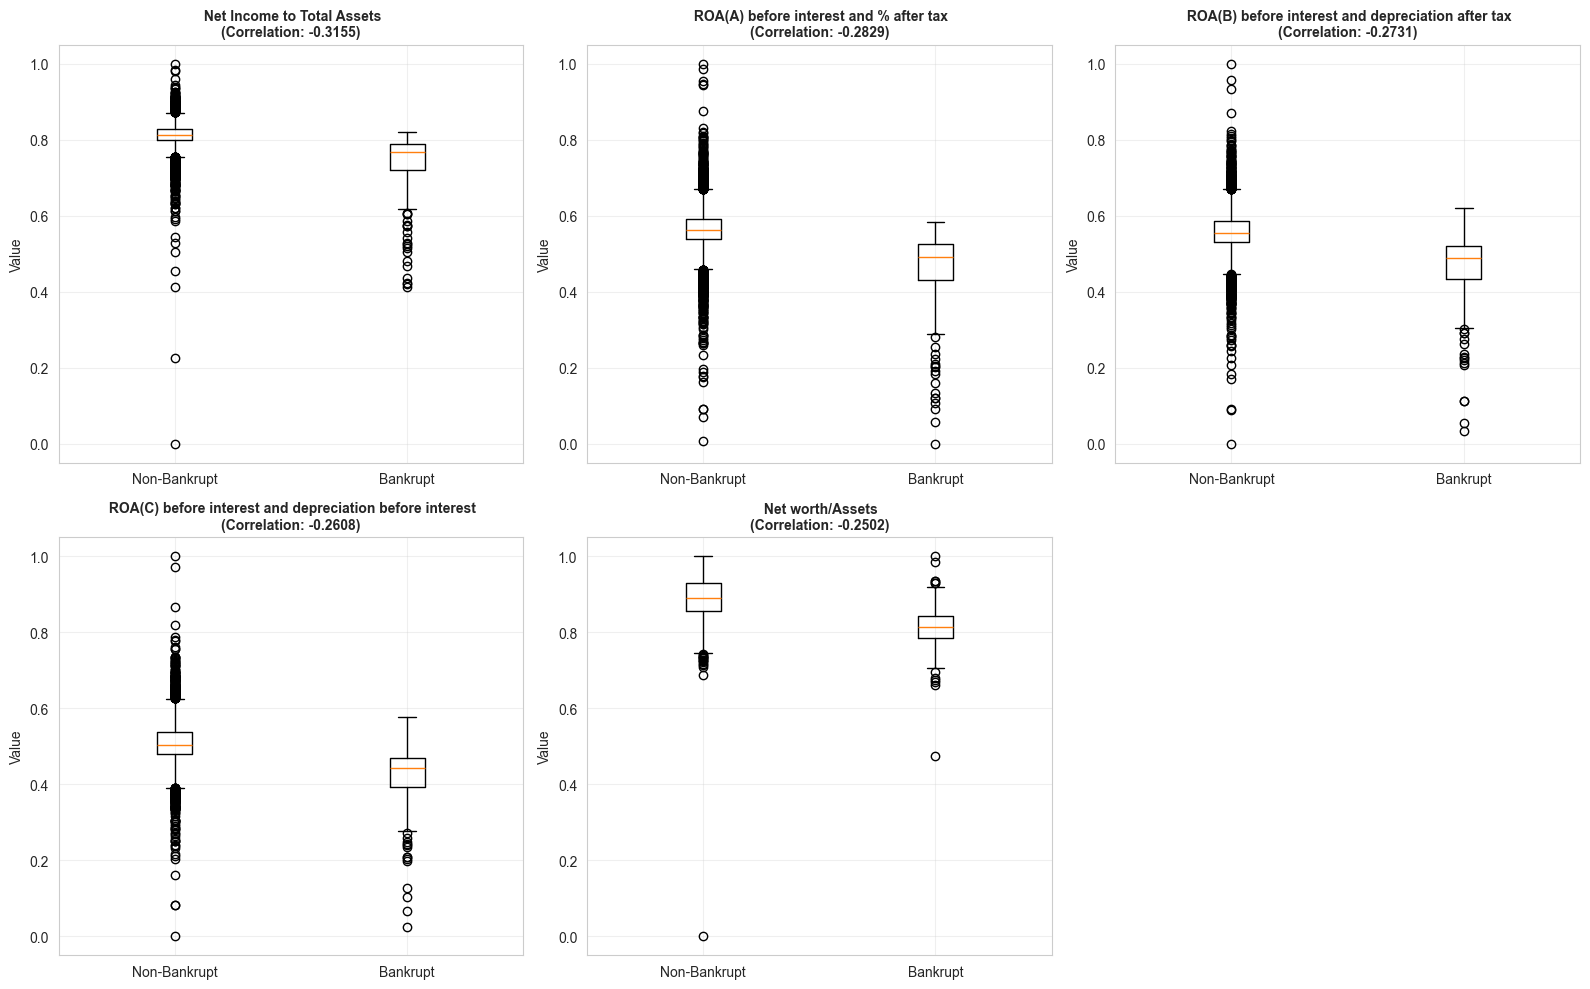

In [47]:
# Compare feature distributions for bankrupt vs non-bankrupt companies
print("\n" + "=" * 80)
print("FEATURE COMPARISON: BANKRUPT vs NON-BANKRUPT")
print("=" * 80)

# Select top 5 most correlated features
top_5_features = correlation_with_target.abs().nlargest(5).index.tolist()
print(f"\nAnalyzing top 5 most correlated features:\n{top_5_features}")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_5_features):
    bankrupt_vals = df[df['Bankrupt?'] == 1][feature]
    non_bankrupt_vals = df[df['Bankrupt?'] == 0][feature]
    
    # Create boxplot
    axes[idx].boxplot([non_bankrupt_vals, bankrupt_vals], labels=['Non-Bankrupt', 'Bankrupt'])
    axes[idx].set_title(f'{feature}\n(Correlation: {correlation_with_target[feature]:.4f})', 
                        fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)
    
    # Print statistics
    print(f"\n{feature}:")
    print(f"  Non-Bankrupt - Mean: {non_bankrupt_vals.mean():.6f}, Std: {non_bankrupt_vals.std():.6f}")
    print(f"  Bankrupt - Mean: {bankrupt_vals.mean():.6f}, Std: {bankrupt_vals.std():.6f}")

# Remove extra subplot
axes[5].remove()

plt.tight_layout()
plt.show()

## 6. Data Quality and Outliers

In [48]:
print("\n" + "=" * 80)
print("DATA QUALITY ANALYSIS")
print("=" * 80)

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Outlier detection using IQR method
print("\nOutlier Detection (IQR method):")
outlier_counts = {}
for col in df.columns:
    if col != 'Bankrupt?':
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        if len(outliers) > 0:
            outlier_counts[col] = len(outliers)

print(f"\nTotal features with outliers: {len(outlier_counts)}")
if outlier_counts:
    print("\nTop 10 features with most outliers:")
    for col, count in sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
        pct = (count / len(df)) * 100
        print(f"  {col}: {count} outliers ({pct:.2f}%)")

# Range analysis
print("\n" + "=" * 80)
print("VALUE RANGE ANALYSIS")
print("=" * 80)

# Check for zero and negative values
print("\nFeatures with negative values:")
for col in df.columns:
    if col != 'Bankrupt?':
        if (df[col] < 0).any():
            neg_count = (df[col] < 0).sum()
            print(f"  {col}: {neg_count} negative values")

print("\nFeatures with zero values:")
zero_features = []
for col in df.columns:
    if col != 'Bankrupt?':
        if (df[col] == 0).any():
            zero_count = (df[col] == 0).sum()
            zero_features.append((col, zero_count))

if zero_features:
    for col, count in zero_features[:10]:
        print(f"  {col}: {count} zero values")
else:
    print("  No features with zero values")


DATA QUALITY ANALYSIS

Duplicate rows: 0

Outlier Detection (IQR method):

Total features with outliers: 89

Top 10 features with most outliers:
   Degree of Financial Leverage (DFL): 1503 outliers (22.04%)
   Interest Coverage Ratio (Interest expense to EBIT): 1421 outliers (20.84%)
   Fixed Assets Turnover Frequency: 1418 outliers (20.79%)
   Current Asset Turnover Rate: 1399 outliers (20.52%)
   Total Asset Growth Rate: 1381 outliers (20.25%)
   Interest Expense Ratio: 1362 outliers (19.97%)
   Cash Flow to Liability: 1212 outliers (17.77%)
   No-credit Interval: 1139 outliers (16.70%)
   Non-industry income and expenditure/revenue: 1094 outliers (16.04%)
   Cash Flow to Sales: 1052 outliers (15.43%)

VALUE RANGE ANALYSIS

Features with negative values:

Features with zero values:
   ROA(C) before interest and depreciation before interest: 1 zero values
   ROA(A) before interest and % after tax: 1 zero values
   ROA(B) before interest and depreciation after tax: 1 zero values
   Op

## 6.5 Data Cleaning & Outlier Treatment

In [49]:
print("\n" + "=" * 80)
print("DATA CLEANING & OUTLIER TREATMENT")
print("=" * 80)

# Create a copy for cleaning
df_cleaned = df.copy()

print(f"\nOriginal dataset shape: {df_cleaned.shape}")

# Method: Winsorization (capping extreme values at percentiles)
from scipy.stats import mstats

print("\nApplying Winsorization (capping at 1st and 99th percentiles)...")

for col in df_cleaned.columns:
    if col != 'Bankrupt?':
        # Cap outliers at 1st and 99th percentiles
        df_cleaned[col] = mstats.winsorize(df_cleaned[col], limits=[0.01, 0.01])

print(f"Cleaned dataset shape: {df_cleaned.shape}")

# Compare statistics before and after cleaning
print("\n" + "-" * 80)
print("STATISTICAL COMPARISON (Top 5 Features)")
print("-" * 80)

top_5_features_list = correlation_with_target.abs().nlargest(5).index.tolist()

for feature in top_5_features_list:
    print(f"\n{feature}:")
    print(f"  Before - Min: {df[feature].min():.6f}, Max: {df[feature].max():.6f}, Std: {df[feature].std():.6f}")
    print(f"  After  - Min: {df_cleaned[feature].min():.6f}, Max: {df_cleaned[feature].max():.6f}, Std: {df_cleaned[feature].std():.6f}")

print("\n✓ Data cleaning complete!")


DATA CLEANING & OUTLIER TREATMENT

Original dataset shape: (6819, 96)

Applying Winsorization (capping at 1st and 99th percentiles)...
Cleaned dataset shape: (6819, 96)

--------------------------------------------------------------------------------
STATISTICAL COMPARISON (Top 5 Features)
--------------------------------------------------------------------------------

 Net Income to Total Assets:
  Before - Min: 0.000000, Max: 1.000000, Std: 0.040332
  After  - Min: 0.679630, Max: 0.888300, Std: 0.033385

 ROA(A) before interest and % after tax:
  Before - Min: 0.000000, Max: 1.000000, Std: 0.065620
  After  - Min: 0.352322, Max: 0.720672, Std: 0.058739

 ROA(B) before interest and depreciation after tax:
  Before - Min: 0.000000, Max: 1.000000, Std: 0.061595
  After  - Min: 0.371754, Max: 0.708443, Std: 0.055783

 ROA(C) before interest and depreciation before interest:
  Before - Min: 0.000000, Max: 1.000000, Std: 0.060686
  After  - Min: 0.337640, Max: 0.664408, Std: 0.055563

 N

## 7. Skewness and Kurtosis


DISTRIBUTION SHAPE ANALYSIS (Skewness & Kurtosis)



Top 10 Features by Skewness (Positive):
                                 Feature  Skewness
                  Fixed Assets to Assets 82.559071
                           Current Ratio 82.559071
              Total income/Total expense 82.314312
                   Net Value Growth Rate 80.274181
        Contingent liabilities/Net worth 79.653094
 Realized Sales Gross Profit Growth Rate 77.907967
       Continuous Net Profit Growth Rate 67.082774
    Total Asset Return Growth Rate Ratio 62.486212
                      Revenue per person 59.421405
          Quick Assets/Current Liability 47.936752


Top 10 Features by Kurtosis (Excess):
                                 Feature    Kurtosis
                  Fixed Assets to Assets 6814.000147
                           Current Ratio 6814.000147
              Total income/Total expense 6786.903523
                   Net Value Growth Rate 6540.116467
        Contingent liabilities/Net worth 6487.125425
 Realized Sales Gross Profit Growth Rate

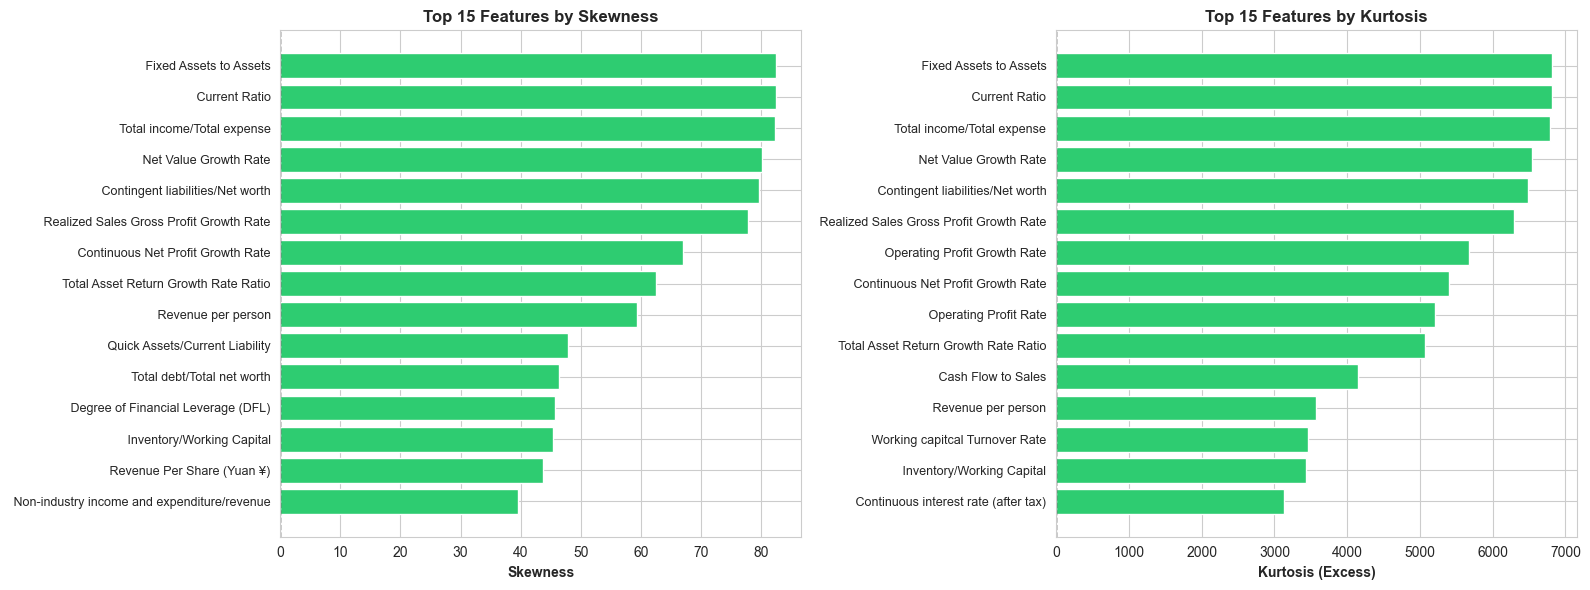

In [50]:
print("\n" + "=" * 80)
print("DISTRIBUTION SHAPE ANALYSIS (Skewness & Kurtosis)")
print("=" * 80)

# Calculate skewness and kurtosis for top features
skewness_data = []
kurtosis_data = []

for col in df.columns:
    if col != 'Bankrupt?':
        skew = stats.skew(df[col])
        kurt = stats.kurtosis(df[col])
        skewness_data.append({'Feature': col, 'Skewness': skew})
        kurtosis_data.append({'Feature': col, 'Kurtosis': kurt})

skewness_df = pd.DataFrame(skewness_data).sort_values('Skewness', ascending=False)
kurtosis_df = pd.DataFrame(kurtosis_data).sort_values('Kurtosis', ascending=False)

print("\nTop 10 Features by Skewness (Positive):")
print(skewness_df.head(10).to_string(index=False))

print("\n\nTop 10 Features by Kurtosis (Excess):")
print(kurtosis_df.head(10).to_string(index=False))

# Visualize skewness and kurtosis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Skewness plot
top_skew = skewness_df.head(15)
colors_skew = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_skew['Skewness']]
axes[0].barh(range(len(top_skew)), top_skew['Skewness'].values, color=colors_skew)
axes[0].set_yticks(range(len(top_skew)))
axes[0].set_yticklabels(top_skew['Feature'].values, fontsize=9)
axes[0].set_xlabel('Skewness', fontweight='bold')
axes[0].set_title('Top 15 Features by Skewness', fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].invert_yaxis()

# Kurtosis plot
top_kurt = kurtosis_df.head(15)
colors_kurt = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_kurt['Kurtosis']]
axes[1].barh(range(len(top_kurt)), top_kurt['Kurtosis'].values, color=colors_kurt)
axes[1].set_yticks(range(len(top_kurt)))
axes[1].set_yticklabels(top_kurt['Feature'].values, fontsize=9)
axes[1].set_xlabel('Kurtosis (Excess)', fontweight='bold')
axes[1].set_title('Top 15 Features by Kurtosis', fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 8. Key Insights and Recommendations

In [51]:
print("\n" + "=" * 80)
print("KEY INSIGHTS & RECOMMENDATIONS")
print("=" * 80)

print("\n📊 DATASET CHARACTERISTICS:")
print(f"  • Total samples: {len(df):,}")
print(f"  • Total features: {df.shape[1]}")
print(f"  • Financial/Ratio metrics: {df.shape[1] - 1} features")
print(f"  • Data type: All numeric")

print("\n⚠️  CLASS IMBALANCE:")
bankrupt_count = (df['Bankrupt?'] == 1).sum()
non_bankrupt_count = (df['Bankrupt?'] == 0).sum()
imbalance_ratio = non_bankrupt_count / bankrupt_count
print(f"  • Non-Bankrupt samples: {non_bankrupt_count:,} ({(non_bankrupt_count/len(df)*100):.2f}%)")
print(f"  • Bankrupt samples: {bankrupt_count:,} ({(bankrupt_count/len(df)*100):.2f}%)")
print(f"  • Imbalance ratio: {imbalance_ratio:.1f}:1")
print(f"  ⚡ RECOMMENDATION: Use class weight balancing, SMOTE, or stratified sampling")

print("\n🔗 TOP PREDICTIVE FEATURES:")
top_5_abs_corr = correlation_with_target.abs().nlargest(5)
for i, (feature, corr) in enumerate(top_5_abs_corr.items(), 1):
    print(f"  {i}. {feature}: {corr:.4f}")

print("\n📈 DATA QUALITY:")
print(f"  • Missing values: 0 ✓")
print(f"  • Duplicate rows: {df.duplicated().sum()}")
print(f"  • Features with negative values: {sum(1 for col in df.columns[:-1] if (df[col] < 0).any())}")
print(f"  • Total outliers detected: {sum(outlier_counts.values())} across {len(outlier_counts)} features")

print("\n🎯 PREPROCESSING RECOMMENDATIONS:")
print("  1. Handle class imbalance (oversampling/undersampling)")
print("  2. Standardize/normalize features (mean-centered values)")
print("  3. Investigate outliers - may be important signals for bankruptcy")
print("  4. Consider feature selection using correlation and domain knowledge")
print("  5. Apply appropriate scaling (StandardScaler or RobustScaler)")
print("  6. Monitor model performance with appropriate metrics (F1, AUC-ROC) given imbalance")

print("\n" + "=" * 80)


KEY INSIGHTS & RECOMMENDATIONS

📊 DATASET CHARACTERISTICS:
  • Total samples: 6,819
  • Total features: 96
  • Financial/Ratio metrics: 95 features
  • Data type: All numeric

⚠️  CLASS IMBALANCE:
  • Non-Bankrupt samples: 6,599 (96.77%)
  • Bankrupt samples: 220 (3.23%)
  • Imbalance ratio: 30.0:1
  ⚡ RECOMMENDATION: Use class weight balancing, SMOTE, or stratified sampling

🔗 TOP PREDICTIVE FEATURES:
  1.  Net Income to Total Assets: 0.3155
  2.  ROA(A) before interest and % after tax: 0.2829
  3.  ROA(B) before interest and depreciation after tax: 0.2731
  4.  ROA(C) before interest and depreciation before interest: 0.2608
  5.  Net worth/Assets: 0.2502

📈 DATA QUALITY:
  • Missing values: 0 ✓
  • Duplicate rows: 0
  • Features with negative values: 0
  • Total outliers detected: 53262 across 89 features

🎯 PREPROCESSING RECOMMENDATIONS:
  1. Handle class imbalance (oversampling/undersampling)
  2. Standardize/normalize features (mean-centered values)
  3. Investigate outliers - ma

## 9. Data Preparation with Oversampling

In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

data_to_use = df_cleaned 
X = data_to_use.drop('Bankrupt?', axis=1)
y = data_to_use['Bankrupt?']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. SCALING (Fit hanya pada Train, lalu Transform ke Train & Test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. OVERSAMPLING HANYA PADA TRAIN SET
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_scaled, y_train)

print(f"Original Train shape: {X_train.shape}")
print(f"Resampled Train shape: {X_train_resampled.shape}")
print(f"Test shape (Original/Imbalanced): {X_test.shape}")


Original Train shape: (5455, 95)
Resampled Train shape: (10558, 95)
Test shape (Original/Imbalanced): (1364, 95)


## 10. Random Forest Model Training

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("\n" + "=" * 80)
print("RANDOM FOREST MODEL TRAINING")
print("=" * 80)

# Initialize and train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

print("\nTraining Random Forest model...")
rf_model.fit(X_train, y_train)
print("✓ Model training complete!")

# Make predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)
y_test_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Calculate metrics
print("\n" + "=" * 80)
print("MODEL PERFORMANCE METRICS")
print("=" * 80)

# Save training metrics for later summary
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

print("\nTRAIN SET:")
print(f"  Accuracy:  {train_accuracy:.4f}")
print(f"  Precision: {train_precision:.4f}")
print(f"  Recall:    {train_recall:.4f}")
print(f"  F1-Score:  {train_f1:.4f}")

print("\nTEST SET:")
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")
print(f"  AUC-ROC:   {test_auc:.4f}")

print("\n" + "-" * 80)
print("CLASSIFICATION REPORT (TEST SET):")
print("-" * 80)
print(classification_report(y_test, y_test_pred, target_names=['Non-Bankrupt', 'Bankrupt']))


RANDOM FOREST MODEL TRAINING

Training Random Forest model...
✓ Model training complete!

MODEL PERFORMANCE METRICS

TRAIN SET:
  Accuracy:  0.9932
  Precision: 1.0000
  Recall:    0.7898
  F1-Score:  0.8825

TEST SET:
  Accuracy:  0.9714
  Precision: 0.6923
  Recall:    0.2045
  F1-Score:  0.3158
  AUC-ROC:   0.9439

--------------------------------------------------------------------------------
CLASSIFICATION REPORT (TEST SET):
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

Non-Bankrupt       0.97      1.00      0.99      1320
    Bankrupt       0.69      0.20      0.32        44

    accuracy                           0.97      1364
   macro avg       0.83      0.60      0.65      1364
weighted avg       0.97      0.97      0.96      1364

✓ Model training complete!

MODEL PERFORMANCE METRICS

TRAIN SET:
  Accuracy:  0.9932
  Precision: 1.0000
  Recall:    0.7898
  F1-Score:  0.8825

TEST SET:

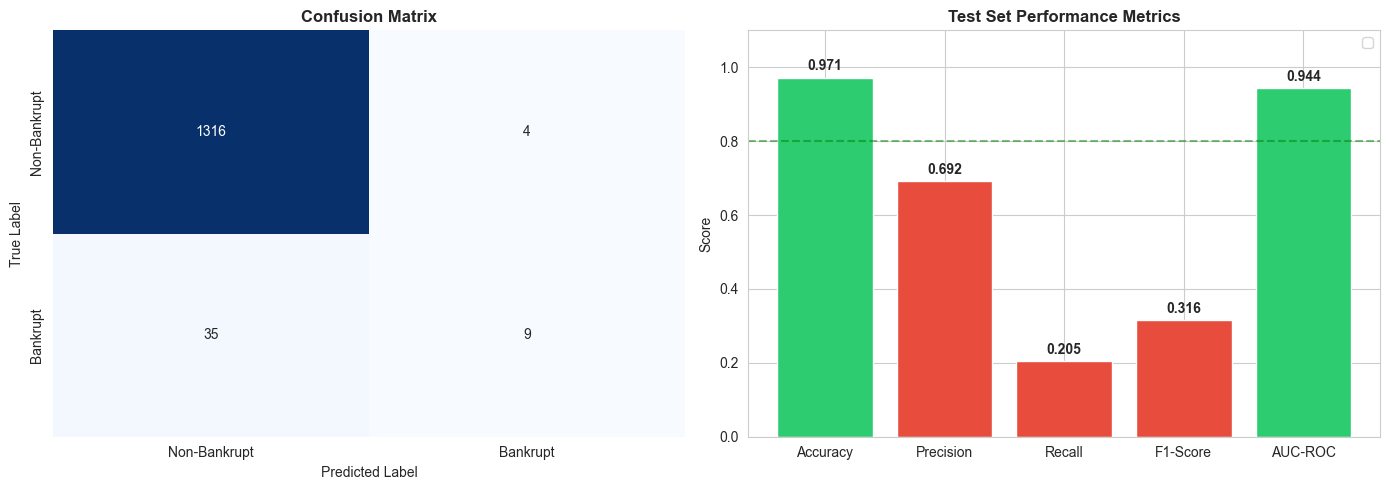

In [54]:
# Visualize confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Non-Bankrupt', 'Bankrupt'], yticklabels=['Non-Bankrupt', 'Bankrupt'])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
values = [test_accuracy, test_precision, test_recall, test_f1, test_auc]
colors_bar = ['#2ecc71' if v >= 0.8 else '#f39c12' if v >= 0.7 else '#e74c3c' for v in values]

axes[1].bar(metrics, values, color=colors_bar)
axes[1].set_ylabel('Score')
axes[1].set_title('Test Set Performance Metrics', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].axhline(y=0.8, color='green', linestyle='--', alpha=0.5)
axes[1].legend()

for i, v in enumerate(values):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Hyper Parameter Tuning

In [55]:
from sklearn.model_selection import RandomizedSearchCV


param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [10, 20, 30, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}


rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)

rf_random.fit(X_train_resampled, y_train_resampled)

print("\nParameter Terbaik yang Ditemukan:")
print(rf_random.best_params_)

best_rf = rf_random.best_estimator_
y_pred_tuned = best_rf.predict(X_test_scaled)

print("\n" + "="*50)
print("PERFORMA SETELAH TUNING (TEST SET)")
print("="*50)
print("\nCONFUSION MATRIX:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_tuned, target_names=['Non-Bankrupt', 'Bankrupt']))

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Parameter Terbaik yang Ditemukan:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 50, 'bootstrap': False}

PERFORMA SETELAH TUNING (TEST SET)

CONFUSION MATRIX:
[[1315    5]
 [  32   12]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

Non-Bankrupt       0.98      1.00      0.99      1320
    Bankrupt       0.71      0.27      0.39        44

    accuracy                           0.97      1364
   macro avg       0.84      0.63      0.69      1364
weighted avg       0.97      0.97      0.97      1364


Parameter Terbaik yang Ditemukan:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 50, 'bootstrap': False}

PERFORMA SETELAH TUNING (TEST SET)

CONFUSION MATRIX:
[[1315    5]
 [  32   12]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

Non-Bankrupt       0.98      1.00      0.99      1320
    Bankr

✅ Menggunakan hasil Hyperparameter Tuning.


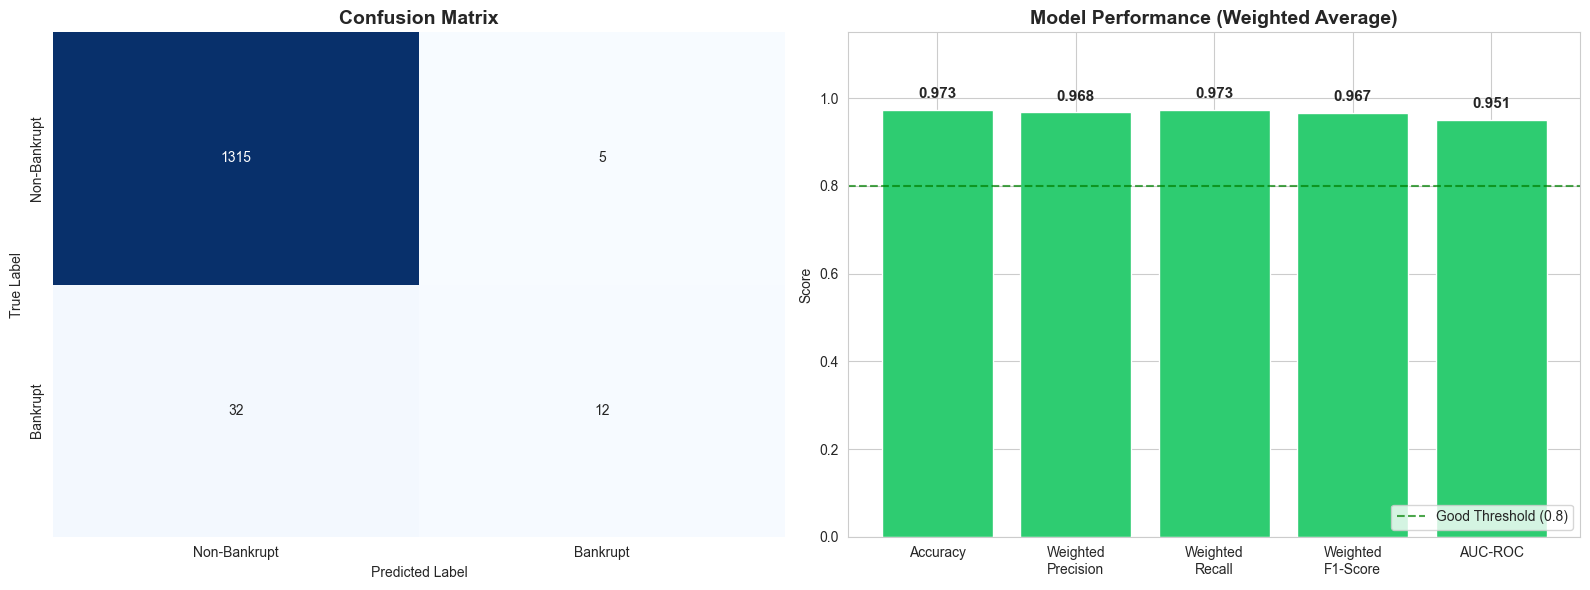

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

try:
    y_pred_final = y_pred_tuned
    model_final = best_rf
    print("✅ Menggunakan hasil Hyperparameter Tuning.")
except NameError:
    print("⚠️ PERINGATAN: Hasil Tuning tidak ditemukan. Menggunakan model RF standar (rf_model).")
    y_pred_final = rf_model.predict(X_test_scaled)
    model_final = rf_model

accuracy = accuracy_score(y_test, y_pred_final)
precision_weighted = precision_score(y_test, y_pred_final, average='weighted')
recall_weighted = recall_score(y_test, y_pred_final, average='weighted')
f1_weighted = f1_score(y_test, y_pred_final, average='weighted')

try:
    y_pred_proba_final = model_final.predict_proba(X_test_scaled)[:, 1]
    auc_score = roc_auc_score(y_test, y_pred_proba_final)
except:
    auc_score = 0
    print("Info: AUC-ROC di-set ke 0 karena probabilitas tidak tersedia.")

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Non-Bankrupt', 'Bankrupt'], yticklabels=['Non-Bankrupt', 'Bankrupt'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

metrics_list = ['Accuracy', 'Weighted\nPrecision', 'Weighted\nRecall', 'Weighted\nF1-Score', 'AUC-ROC']
values_list = [accuracy, precision_weighted, recall_weighted, f1_weighted, auc_score]

colors_bar = ['#2ecc71' if v >= 0.8 else '#f39c12' if v >= 0.7 else '#e74c3c' for v in values_list]

bars = axes[1].bar(metrics_list, values_list, color=colors_bar)
axes[1].set_ylabel('Score')
axes[1].set_title('Model Performance (Weighted Average)', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].axhline(y=0.8, color='green', linestyle='--', alpha=0.7, label='Good Threshold (0.8)')
axes[1].legend(loc='lower right')

# Menambahkan label angka di atas batang
for bar, val in zip(bars, values_list):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', 
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

✅ Menggunakan model hasil Tuning (best_rf)

TOP 5 FITUR PALING BERPENGARUH
                                     Feature  Importance
35                Total debt/Total net worth    0.051974
18   Persistent EPS in the Last Four Seasons    0.049081
39                      Borrowing dependency    0.047790
9       Continuous interest rate (after tax)    0.046718
85                Net Income to Total Assets    0.042021

TOP 5 FITUR PALING BERPENGARUH
                                     Feature  Importance
35                Total debt/Total net worth    0.051974
18   Persistent EPS in the Last Four Seasons    0.049081
39                      Borrowing dependency    0.047790
9       Continuous interest rate (after tax)    0.046718
85                Net Income to Total Assets    0.042021


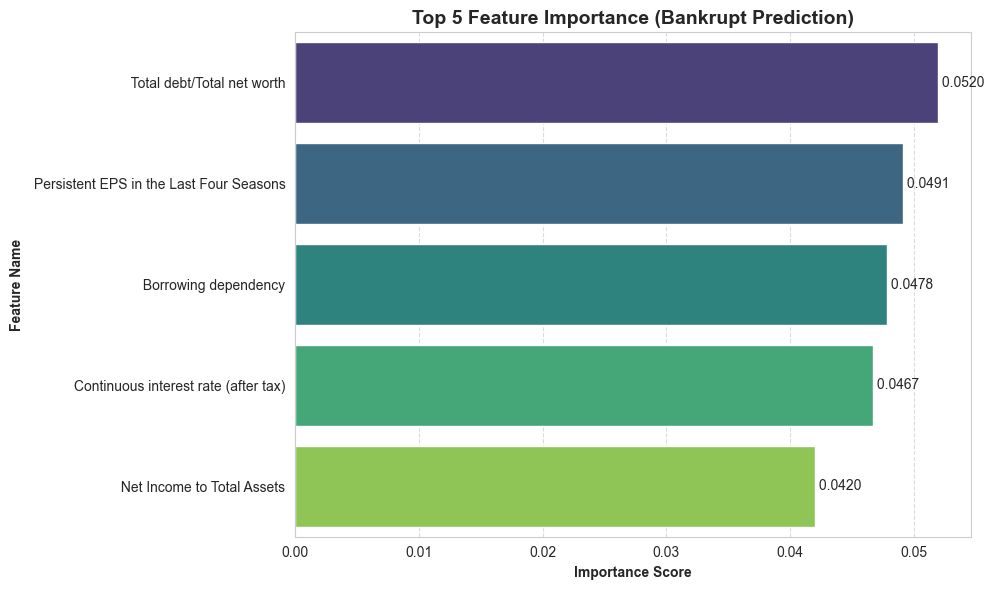

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    target_model = best_rf
    print("✅ Menggunakan model hasil Tuning (best_rf)")
except NameError:
    target_model = rf_model
    print("⚠️ Menggunakan model standar (rf_model) karena hasil tuning tidak ditemukan.")

feature_importance = target_model.feature_importances_
feature_names = X.columns

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

top_5_features = fi_df.sort_values(by='Importance', ascending=False).head(5)

print("\n" + "="*40)
print("TOP 5 FITUR PALING BERPENGARUH")
print("="*40)
print(top_5_features)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_5_features, palette='viridis')

plt.title('Top 5 Feature Importance (Bankrupt Prediction)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontweight='bold')
plt.ylabel('Feature Name', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Tampilkan nilai di ujung bar
for index, value in enumerate(top_5_features['Importance']):
    plt.text(value, index, f' {value:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()